In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("../Datasets/Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.describe(include='object')

C:\Users\arpit\AppData\Local\Temp\ipykernel_1672\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [11]:
summary=pd.DataFrame(
    {
        "Data Type":df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique()
    }
)
summary

,Data Type,Missing Values,Unique Values
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,str,0,891
Sex,str,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Ticket,str,0,681
Fare,float64,0,248


In [12]:
# Univariate Analysis

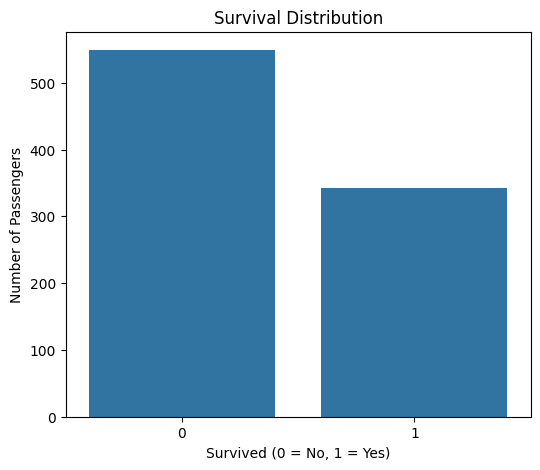

In [13]:
# Survival Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.savefig("images/survival_distribution.png", dpi=300)

plt.show()

In [14]:
survival_percent = df["Survived"].value_counts(normalize=True) * 100
print(survival_percent)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [15]:
### Observation
#- More passengers did not survive than survived.
#- Around 38% of passengers survived, while about 62% did not.

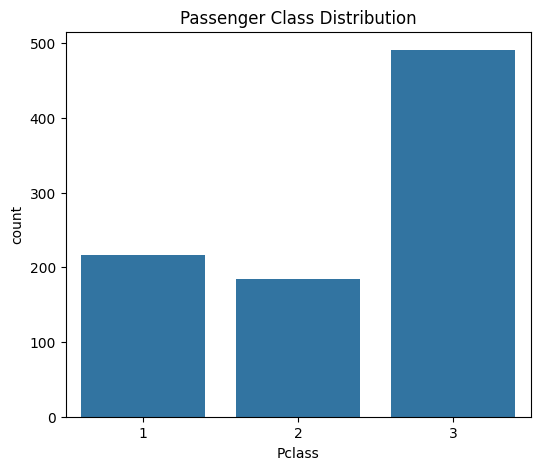

In [16]:
# Passenger Class Analysis
plt.figure(figsize=(6,5))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.savefig("images/pclass_distribution.png", dpi=300)

plt.show()

In [17]:
print(df["Pclass"].value_counts())
print(df["Pclass"].value_counts(normalize=True) * 100)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64


In [18]:
### Observation
#- Third-class passengers form the largest group.
#- First-class passengers are the smallest group.

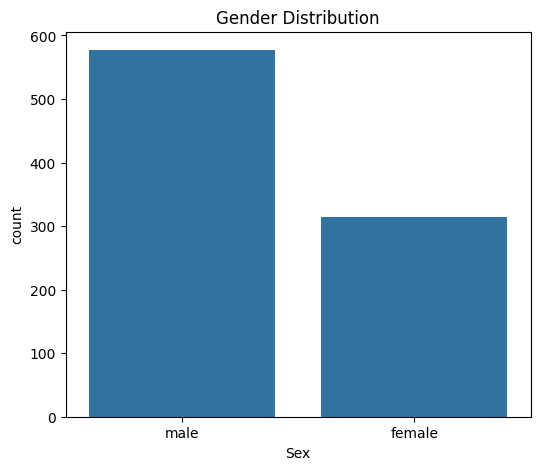

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.savefig("images/sex_distribution.png", dpi=300)

plt.show()

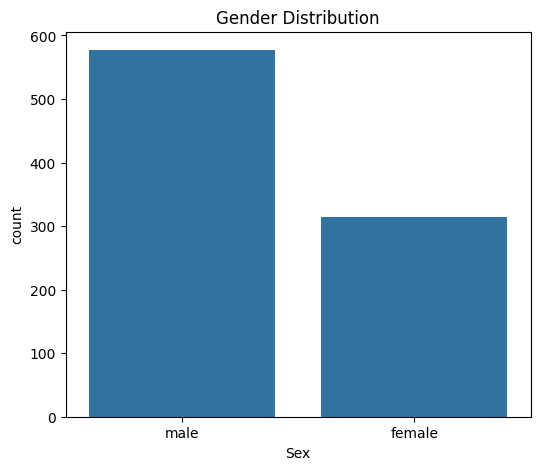

In [20]:
#Gender Analysis
plt.figure(figsize=(6,5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.savefig("images/sex_distribution.png", dpi=300)

plt.show()

In [21]:
print(df["Sex"].value_counts())
print(df["Sex"].value_counts(normalize=True) * 100)

Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


In [22]:
### Observation
#- Male passengers are more than female passengers.

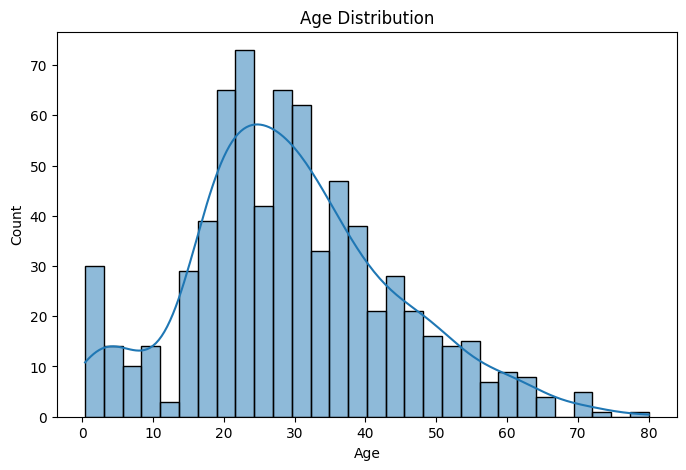

In [23]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.savefig("images/age_distribution.png", dpi=300)

plt.show()

In [24]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [25]:
### Observation
#- Most passengers are between 20 and 40 years old.
#- The distribution is slightly right-skewed.

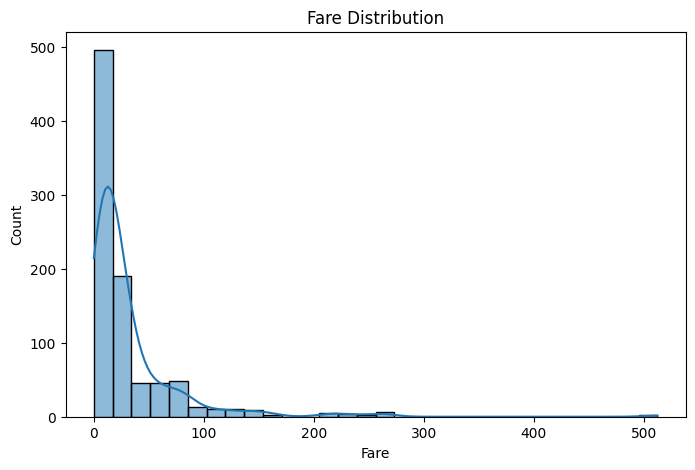

In [26]:
# Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.savefig("images/fare_distribution.png", dpi=300)

plt.show()

In [27]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [28]:
### Observation
# - Most passengers paid lower fares.
#- A few passengers paid very high fares, causing right skewness.

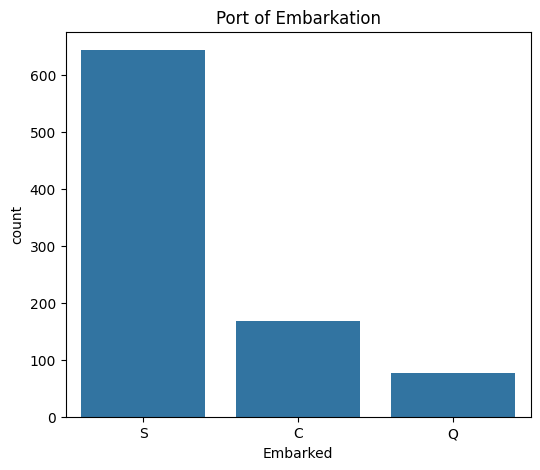

In [29]:
# Embarked Analysis
plt.figure(figsize=(6,5))

sns.countplot(x="Embarked", data=df)

plt.title("Port of Embarkation")

plt.savefig("images/embarked_distribution.png", dpi=300)

plt.show()

In [30]:
print(df["Embarked"].value_counts())
print(df["Embarked"].value_counts(normalize=True) * 100)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64


In [31]:
# Bivariate Analysis

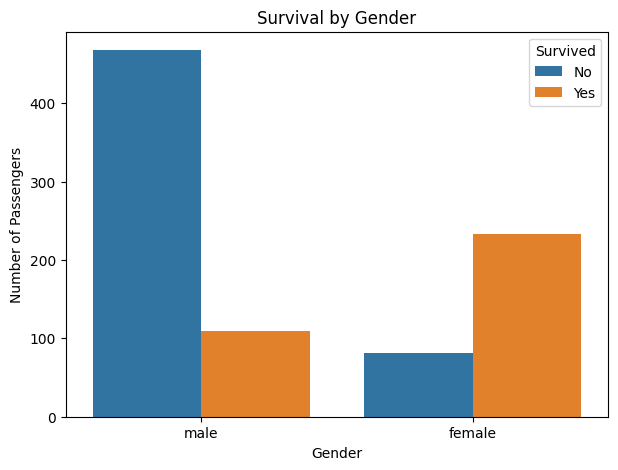

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Survival by Gender
# ensure df is available (will load if not present in the notebook namespace)
if 'df' not in globals():
	df = pd.read_csv("../Datasets/Titanic-Dataset.csv")

plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("images/survival_by_gender.png", dpi=300)

plt.show()

In [33]:
gender_survival = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print(gender_survival)

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


In [34]:
### Observation
# - Female passengers had a significantly higher survival rate than male passengers.
# - Male passengers experienced a higher number of fatalities.

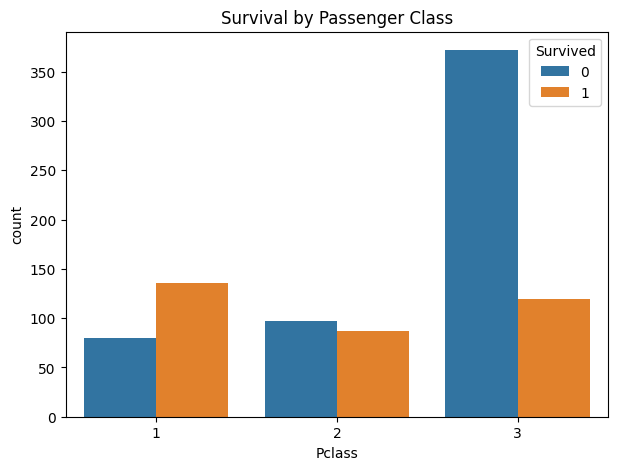

In [35]:
# Survival vs Passenger Class
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.savefig("images/survival_by_class.png", dpi=300)

plt.show()

In [36]:
class_survival = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

print(class_survival)

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


In [37]:
### Observation
# - First-class passengers had the highest survival rate.
# - Third-class passengers had the lowest survival rate.

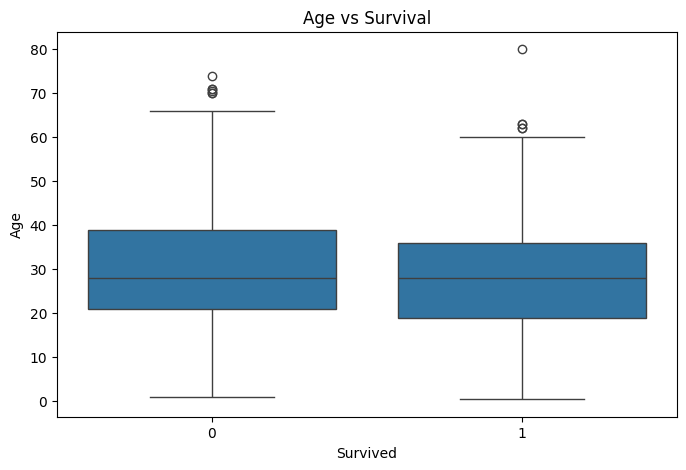

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age vs Survival")

plt.savefig("images/age_vs_survival.png", dpi=300)

plt.show()

In [39]:
### Observation
# - The age distributions overlap considerably.
# - Both younger and older passengers are represented among survivors and non-survivors.

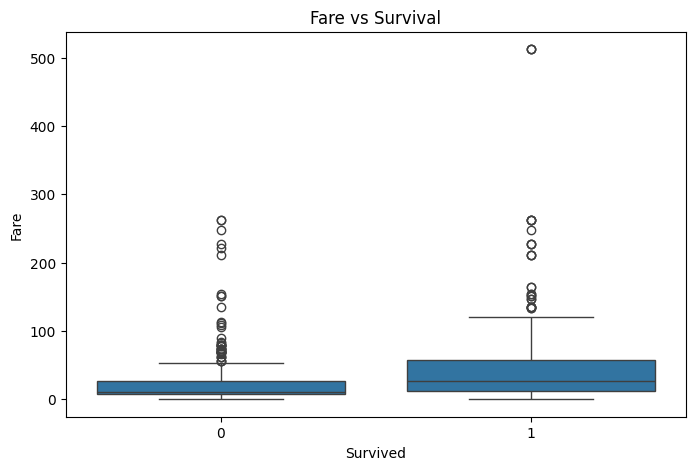

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Fare vs Survival")

plt.savefig("images/fare_vs_survival.png", dpi=300)

plt.show()

In [41]:
### Observation
# - Passengers who survived generally paid higher fares.
# - Higher ticket fare appears to be associated with a greater chance of survival.

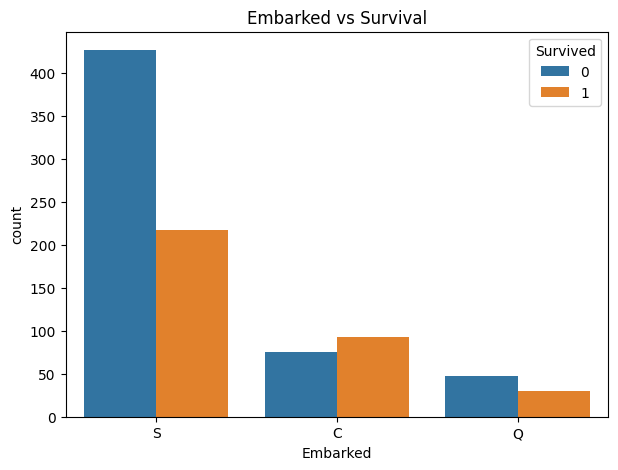

In [42]:
plt.figure(figsize=(7,5))

sns.countplot(x="Embarked", hue="Survived", data=df)

plt.title("Embarked vs Survival")

plt.savefig("images/embarked_vs_survival.png", dpi=300)

plt.show()

In [43]:
embarked_survival = pd.crosstab(
    df["Embarked"],
    df["Survived"],
    normalize="index"
) * 100

print(embarked_survival)

Survived          0          1
Embarked                      
C         44.642857  55.357143
Q         61.038961  38.961039
S         66.304348  33.695652


In [44]:
### Observation
# - Survival rates differ among embarkation ports.
# - Southampton (S) contributed the largest number of passengers.

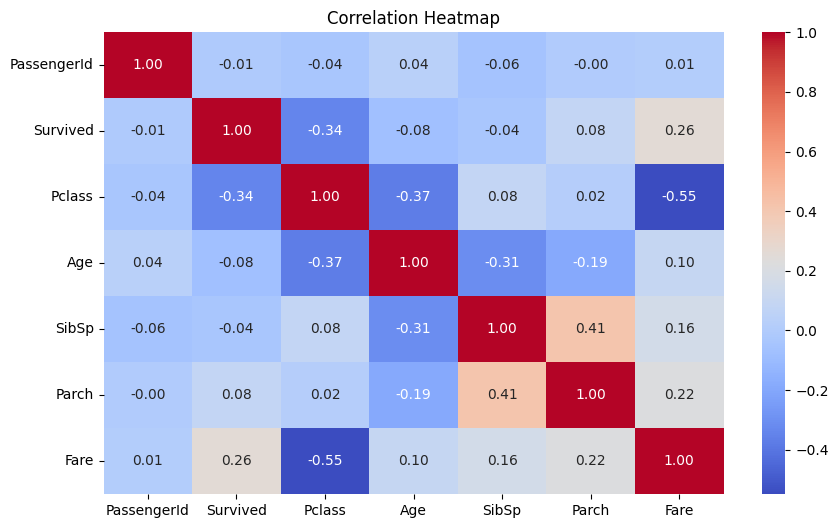

In [45]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300)

plt.show()

In [46]:
### Observation
# - Survival has a negative correlation with passenger class.
# - Fare is positively correlated with survival.
# - Most other numerical relationships are weak.

In [ ]:
# Multivariate Analysis


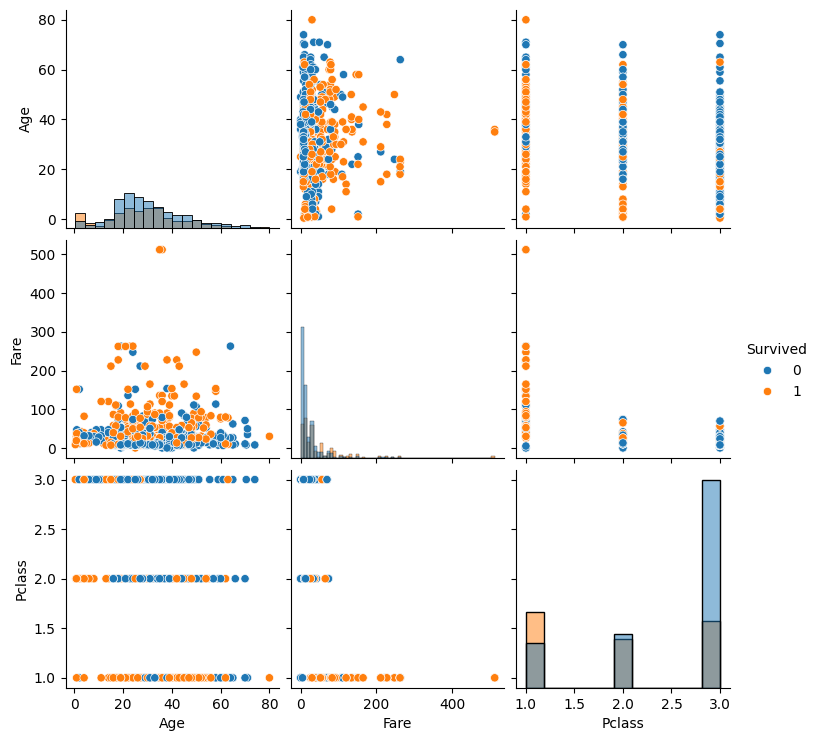

In [47]:
# Pair plot
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]],
    hue="Survived",
    diag_kind="hist"
)

plt.savefig("images/pairplot.png", dpi=300)
plt.show()

In [ ]:
### Observation
#- Fare and passenger class show a noticeable relationship.
#- Survivors tend to appear more frequently among higher-fare passengers.
#- Age alone does not clearly separate survivors from non-survivors.

In [48]:
# Survival by Gender and Passenger Class
survival_table = pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
)

print(survival_table)

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


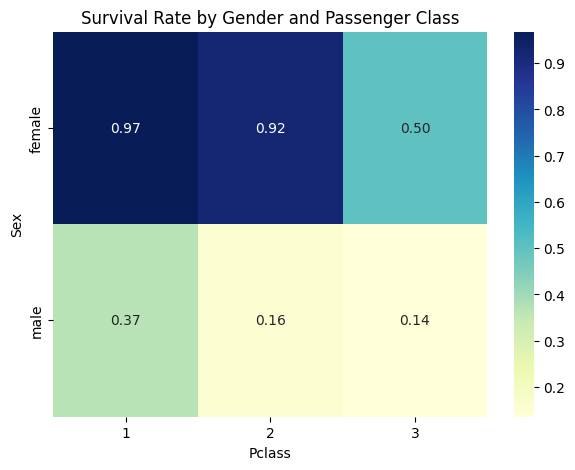

In [49]:
plt.figure(figsize=(7,5))

sns.heatmap(
    survival_table,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Survival Rate by Gender and Passenger Class")

plt.savefig("images/gender_class_heatmap.png", dpi=300)

plt.show()

In [ ]:
### Observation
# - Female passengers had high survival rates across all classes.
# - First-class females had the highest survival rate.
# - Third-class males had the lowest survival rate.

In [50]:
# Average Fare by Passenger
fare_class = df.groupby("Pclass")["Fare"].mean()

print(fare_class)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


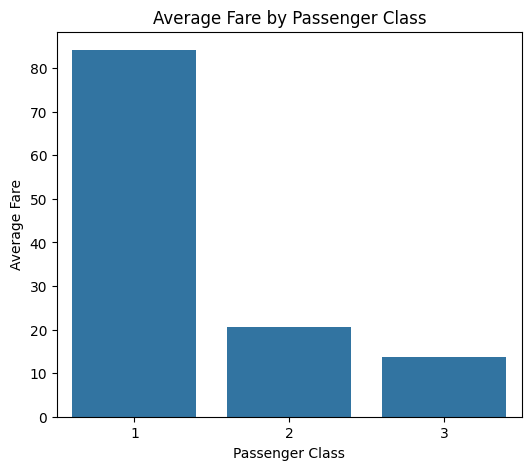

In [51]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=fare_class.index,
    y=fare_class.values
)

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.savefig("images/average_fare_by_class.png", dpi=300)

plt.show()

In [ ]:
### Observation
# - First-class passengers paid the highest average fares.
# - Third-class passengers paid the lowest average fares.

In [52]:
# Average Age by Passenger Class
age_class = df.groupby("Pclass")["Age"].mean()

print(age_class)

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


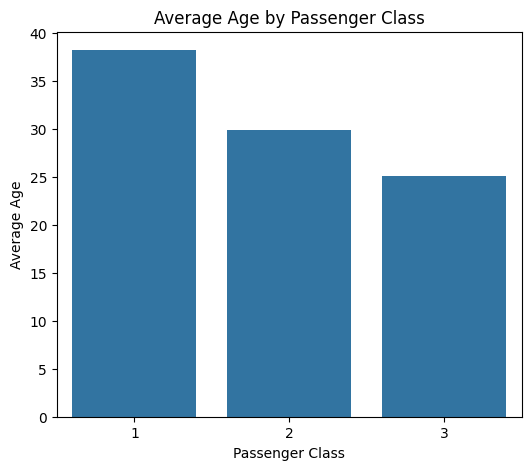

In [53]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=age_class.index,
    y=age_class.values
)

plt.title("Average Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Age")

plt.savefig("images/average_age_by_class.png", dpi=300)

plt.show()

In [ ]:
### Observation
# - First-class passengers were generally older.
# - Third-class passengers had a lower average age.

In [54]:
# Top 10 Most Expensive Tickets
top_fares = df.nlargest(10, "Fare")

top_fares[["Name", "Pclass", "Fare", "Survived"]]

,Name,Pclass,Fare,Survived
258,"Ward, Miss. Anna",1,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
737,"Lesurer, Mr. Gustave J",1,512.3292,1
27,"Fortune, Mr. Charles Alexander",1,263.0000,0
88,"Fortune, Miss. Mabel Helen",1,263.0000,1
341,"Fortune, Miss. Alice Elizabeth",1,263.0000,1
438,"Fortune, Mr. Mark",1,263.0000,0
311,"Ryerson, Miss. Emily Borie",1,262.3750,1
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750,1
118,"Baxter, Mr. Quigg Edmond",1,247.5208,0


In [ ]:
### Observation
# - The highest fares were mostly associated with first-class passengers.
# - Many passengers with expensive tickets survived.

In [ ]:
""" Final Insights
  Key Findings

1. Female passengers had a much higher survival rate than male passengers.

2. First-class passengers had the highest survival rate.

3. Most passengers were between 20 and 40 years old.

4. Third-class passengers formed the largest group.

5. Fare had a positive relationship with survival.

6. Age had a weaker relationship with survival than gender or passenger class.

7. Southampton (S) was the busiest embarkation port.

8. Higher-paying passengers generally had better survival outcomes """